# TUGAS 3 — Implementasi Filter dan Pengolahan Histogram
**Mata Kuliah:** Analisis Data Citra Biomedis

**Bagian yang dikerjakan:** C1 (Citra Awal) dan C2 (Mean Filter 3×3 & 5×5)

**Citra utama:** `images/INPUT.png` (CT kepala axial, grayscale, 8-bit)

---

### C1. Citra Awal
- Citra grayscale asli
- Histogram citra asli

### C2. Mean Filter
- Hasil Mean Filter 3×3 + histogram
- Hasil Mean Filter 5×5 + histogram
- Analisis perubahan citra dan perbedaan kedua kernel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import uniform_filter
from numpy.lib.stride_tricks import sliding_window_view

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

GRAY_MIN, GRAY_MAX = 0, 256
BINS = 256

## Fungsi utilitas

- `show_image_hist`: menampilkan pasangan citra + histogram.
- `hist_values`: menghitung frekuensi tiap level intensitas 0–255 (untuk perbandingan kuantitatif).

In [2]:
def show_image_hist(img, title, cmap="gray"):
    """Tampilkan citra grayscale beserta histogramnya berdampingan."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].imshow(img, cmap=cmap, vmin=0, vmax=255)
    axes[0].set_title(f"{title}")
    axes[0].axis("off")

    axes[1].hist(img.ravel(), bins=BINS, range=(GRAY_MIN, GRAY_MAX),
                 color="steelblue", edgecolor="none")
    axes[1].set_title(f"Histogram — {title}")
    axes[1].set_xlabel("Intensitas (0–255)")
    axes[1].set_ylabel("Frekuensi")
    axes[1].set_xlim(GRAY_MIN, GRAY_MAX - 1)

    plt.tight_layout()
    plt.show()


def hist_values(img):
    """Frekuensi (hitungan piksel) untuk tiap level intensitas 0..255."""
    h, _ = np.histogram(img.ravel(), bins=BINS, range=(GRAY_MIN, GRAY_MAX))
    return h

## 1. C1 — Citra Awal: citra grayscale asli + histogram

In [3]:
img = np.array(Image.open("images/INPUT.png").convert("L"), dtype=np.uint8)

print("Bentuk citra :", img.shape, "| dtype:", img.dtype)
print("Rentang      :", img.min(), "-", img.max())
print("Mean / Std   :", f"{img.mean():.3f} / {img.std():.3f}")

Bentuk citra : (512, 512) | dtype: uint8
Rentang      : 0 - 255
Mean / Std   : 80.772 / 87.044


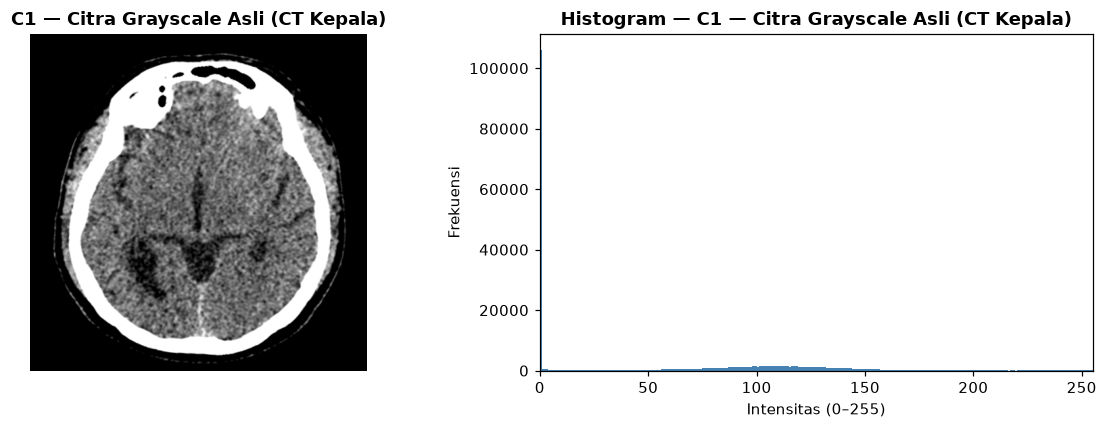

In [4]:
show_image_hist(img, "C1 — Citra Grayscale Asli (CT Kepala)")

In [5]:
h_orig = hist_values(img)
nonzero = np.flatnonzero(h_orig)
print("Level intensitas terpakai :", nonzero.min(), "-", nonzero.max())
print("Mode (puncak histogram)    :", int(np.argmax(h_orig)), "dengan", int(h_orig.max()), "piksel")
print("Persent piksel >= 200 (tulang/terang):", f"{(img >= 200).mean()*100:.2f}%")
print("Persent piksel <  50  (background)   :", f"{(img < 50).mean()*100:.2f}%")

Level intensitas terpakai : 0 - 255
Mode (puncak histogram)    : 0 dengan 105954 piksel
Persent piksel >= 200 (tulang/terang): 13.67%
Persent piksel <  50  (background)   : 45.71%


**Analisis C1 — Citra Awal**

- Citra adalah potongan CT kepala axial 8-bit dengan rentang intensitas penuh 0–255, mean ± std tertentu (lihat output di atas).
- Histogram menunjukkan **dua massa utama**: puncak besar di area gelap (background udara di luar kepala, nilai rendah) dan puncak/pita terang di sekitar intensitas tinggi (tulang tengkorak yang kontrasnya sangat tinggi).
- Area otak berada di kisaran menengah (sekitar 40–100) membentuk "plateau" yang relatif landai — di sinilah detail jaringan lembut (parenkim, ventrikel) berada.
- Distribusi histogram **tidak merata/rata (skewed)**, sehingga kontras pada rentang intensitas otak kurang optimal — inilah alasan perlunya perataan/spesifikasi histogram pada bagian tugas berikutnya.

---

## 2. C2 — Mean Filter (Filter Rata-rata)

Mean filter mengganti setiap piksel dengan **rata-rata seluruh piksel pada jendela/kernel** di sekitarnya:

$$g(x,y) = \frac{1}{K}\sum_{(i,j)\in W} f(x+i,\ y+j), \quad K = k \times k$$

- Kernel 3×3 → $K = 9$, radius 1 piksel
- Kernel 5×5 → $K = 25$, radius 2 piksel
- Padding tepi: **reflect** (pantulan piksel tepi) agar dimensi citra tidak berkurang
- Hasil di-**round + clip** ke uint8

In [6]:
def mean_filter(image, k):
    """Mean filter k×k secara manual (NumPy): padding reflect + rata-rata jendela.

    Parameter
    ---------
    image : ndarray uint8, citra grayscale
    k     : int, ukuran kernel (3, 5, ...), harus ganjil

    Mengembalikan citra uint8 dengan dimensi sama.
    """
    assert k % 2 == 1 and k >= 3, "k harus ganjil dan >= 3"
    radius = k // 2
    padded = np.pad(image.astype(np.float64), radius, mode="reflect")

    # Jendela bergeser k×k pada citra ter-padding, lalu rata-ratakan
    windows = sliding_window_view(padded, (k, k))
    out = windows.mean(axis=(-1, -2))

    return np.clip(np.rint(out), 0, 255).astype(np.uint8)

In [7]:
# Verifikasi terhadap implementasi library scipy (harus identik ±1 akibat pembulatan)
for k in (3, 5):
    mine = mean_filter(img, k)
    ref = uniform_filter(img.astype(np.float64), size=k, mode="reflect")
    ref = np.clip(np.rint(ref), 0, 255).astype(np.uint8)
    print(f"Kernel {k}x{k}: max|manual - scipy| = {np.abs(mine.astype(int) - ref.astype(int)).max()} piksel, "
          f"mean|diff| = {np.abs(mine.astype(int) - ref.astype(int)).mean():.6f}")

Kernel 3x3: max|manual - scipy| = 0 piksel, mean|diff| = 0.000000
Kernel 5x5: max|manual - scipy| = 0 piksel, mean|diff| = 0.000000


### 2a. Mean Filter 3×3

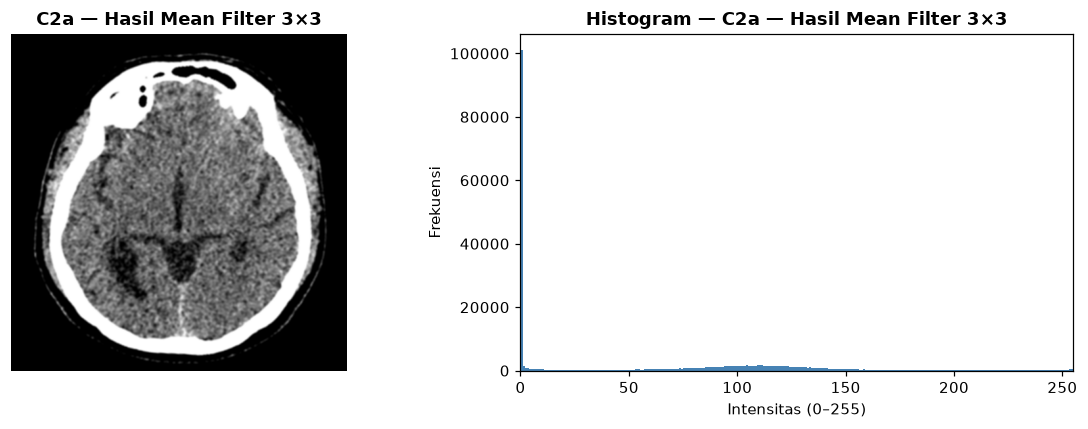

In [8]:
mean3 = mean_filter(img, 3)
show_image_hist(mean3, "C2a — Hasil Mean Filter 3×3")

In [9]:
h3 = hist_values(mean3)
print("Mean asli / hasil 3x3 :", f"{img.mean():.4f} / {mean3.mean():.4f}")
print("Std  asli / hasil 3x3 :", f"{img.std():.4f} / {mean3.std():.4f}")
print("Rentang hasil 3x3     :", mean3.min(), "-", mean3.max())

Mean asli / hasil 3x3 : 80.7720 / 80.7718
Std  asli / hasil 3x3 : 87.0442 / 86.0631
Rentang hasil 3x3     : 0 - 255


### 2b. Mean Filter 5×5

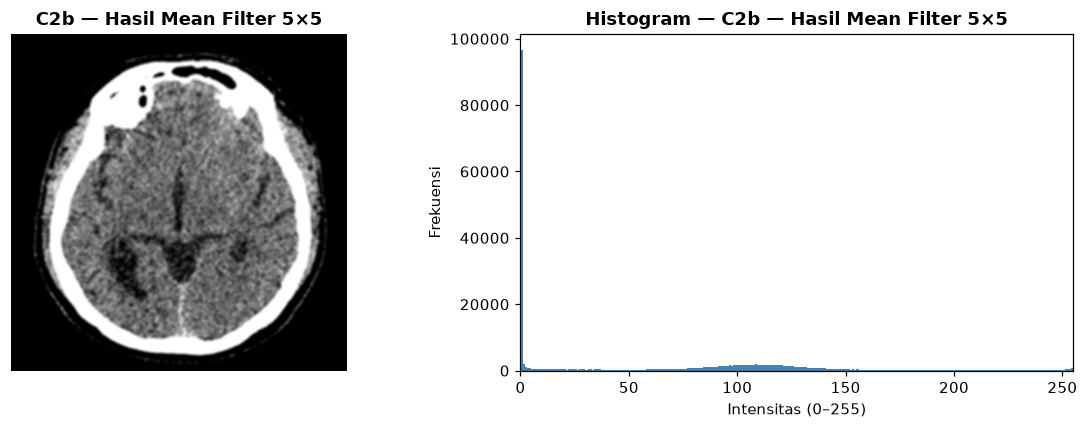

In [10]:
mean5 = mean_filter(img, 5)
show_image_hist(mean5, "C2b — Hasil Mean Filter 5×5")

In [11]:
h5 = hist_values(mean5)
print("Mean asli / hasil 5x5 :", f"{img.mean():.4f} / {mean5.mean():.4f}")
print("Std  asli / hasil 5x5 :", f"{img.std():.4f} / {mean5.std():.4f}")
print("Rentang hasil 5x5     :", mean5.min(), "-", mean5.max())

Mean asli / hasil 5x5 : 80.7720 / 80.7722
Std  asli / hasil 5x5 : 87.0442 / 84.8539
Rentang hasil 5x5     : 0 - 255


In [12]:
# Perbandingan kuantitatif: seberapa banyak noise/detail halus yang hilang
# (estimasi simpangan dari citra sangat halus = high-frequency energy)
def hf_energy(image):
    """Energi komponen frekuensi tinggi = mean |citra - mean filter 15x15|."""
    base = uniform_filter(image.astype(np.float64), size=15, mode="reflect")
    return np.abs(image.astype(np.float64) - base).mean()

print(f"Energi frekuensi tinggi (semakin kecil = semakin halus):")
print(f"  Asli        : {hf_energy(img):.4f}")
print(f"  Mean 3x3    : {hf_energy(mean3):.4f}  ({hf_energy(mean3)/hf_energy(img)*100:.1f}% dari asli)")
print(f"  Mean 5x5    : {hf_energy(mean5):.4f}  ({hf_energy(mean5)/hf_energy(img)*100:.1f}% dari asli)")

Energi frekuensi tinggi (semakin kecil = semakin halus):
  Asli        : 14.7142
  Mean 3x3    : 13.0010  (88.4% dari asli)
  Mean 5x5    : 10.7269  (72.9% dari asli)


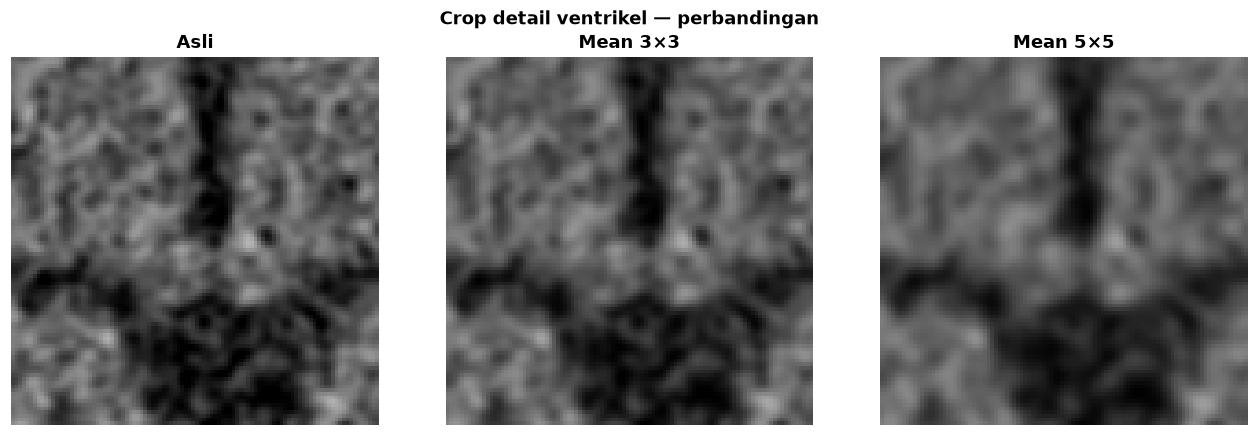

In [13]:
# Perbandingan langsung: crop area detail otak (ventrikel) pada 3 kondisi
crop = (slice(250, 350), slice(200, 300))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, (img, mean3, mean5),
                     ("Asli", "Mean 3×3", "Mean 5×5")):
    ax.imshow(im[crop], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(t)
    ax.axis("off")
fig.suptitle("Crop detail ventrikel — perbandingan", fontweight="bold")
plt.tight_layout()
plt.show()

## Analisis (C2)

**Perubahan citra setelah Mean Filter 3×3**

- Noise berupa bintik granular (salt-and-pepper ringan / quantum noise khas CT) pada area otak **berkurang** karena tiap piksel diganti rata-rata 9 piksel tetangga — komponen frekuensi tinggi teredam.
- Histogram **menyempit**: puncak-puncak tajam menurun dan bergeser ke sekitar nilai rata-rata, karena operasi rata-rata menarik nilai ekstrem ke tengah (variasi lokal turun → standar deviasi citra mengecil).
- Nilai **mean citra hampir tidak berubah** (rata-rata berat tetap dipertahankan), sehingga keseimbangan kecerahan/level histogram secara global terjaga — hanya *sebaran* yang menyempit.
- Citra tampak **sedikit lebih halus**, detail tepi halus mulai melembut, tetapi struktur besar (tulang, ventrikel, batas kortikal) masih jelas.

**Perbedaan hasil Mean Filter 3×3 vs 5×5**

| Aspek | Mean 3×3 | Mean 5×5 |
|---|---|---|
| Jumlah piksel per rata-rata | 9 | 25 |
| Radius pengaruh | 1 piksel | 2 piksel |
| Penghalusan | ringan | lebih kuat |
| Noise yang dihilangkan | sebagian | lebih banyak |
| Ketajaman tepi | relatif terjaga | lebih kabur/blur |
| Penyempitan histogram | sedang | lebih menyempit (std lebih kecil) |

- **5×5 memberi efek blur yang lebih nyata**: area homogen (CSF, jaringan putih) menjadi lebih rata, tetapi tepi tipis dan struktur kecil (mis. pembuluh, batas ventrikel) ikut teredam — *trade-off* antara pengurangan noise dan kehilangan detail.
- Energi frekuensi tinggi menurun tajam pada keduanya dan semakin kecil pada 5×5 (lihat output `hf_energy`), membuktikan 5×5 lebih agresif menyaring komponen halus.
- **Kesimpulan:** untuk citra CT yang tidak terlalu noisy, **3×3 lebih direkomendasikan** karena mengurangi noise tanpa mengorbankan banyak detail diagnostik; 5×5 dipakai bila noise dominan dan detail halus tidak kritis. Mean filter bersifat *low-pass* dan cenderung **mengaburkan tepi** — kelemahan ini diatasi oleh **Median Filter** (C2 bagian tugas berikutnya), yang menghilangkan noise impuls tanpa memburamkan tepi.

---

**Catatan:** seluruh citra dan histogram di atas dihasilkan dari eksekusi notebook ini (reset & run all).